In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/featured_data.csv')
print(f"Shape: {df.shape}")

X = df.drop(columns=['TARGET'])
y = df['TARGET']
print(f"Features: {X.shape[1]}, Target: {y.value_counts().to_dict()}")

Shape: (307511, 185)
Features: 184, Target: {0: 282686, 1: 24825}


In [2]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(X)

low_variance_cols = X.columns[~selector.get_support()].tolist()
print(f"Low variance columns to drop: {len(low_variance_cols)}")
print(low_variance_cols)

X = X.drop(columns=low_variance_cols)
print(f"Shape after variance filter: {X.shape}")

Low variance columns to drop: 78
['REGION_POPULATION_RELATIVE', 'FLAG_MOBIL', 'FLAG_CONT_MOBILE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'CODE_GENDER_XNA', 'NAME_TYPE_SUITE_Group of people', 'NAME_TYPE_SUITE_Other_A', 'NAME_TYPE_SUITE_Other_B', 'NAME_INCOME_TYPE_Maternity leave', 'NAME_INCOME_TYPE_Student', 'NAME_INCOME_TYPE_Unemployed', 'NAME_FAMILY_STATUS_Unknown', 'NAME_HOUSING_TYPE_Office apartment', 'OCCUPATION_TYPE_HR staff', 'OCCUPATION_TYPE_IT staff', 'OCCUPATION_TYPE_Low-skill Laborers', 'OCCUPATION_TYPE_Private service staff', 'OCCUPATION_TYPE_Realty agents', 'OCCUPATION_TYPE_Secretaries', 'OCCUPATION_TYPE_Waiters/barmen staff', 'ORGANIZATION_TYPE_Agriculture', 'ORGANIZATION

In [3]:
# Compute correlation matrix
corr_matrix = X.corr().abs()

# Get upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find columns with correlation > 0.85
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.85)]
print(f"Highly correlated columns to drop: {len(high_corr_cols)}")
print(high_corr_cols)

X = X.drop(columns=high_corr_cols)
print(f"Shape after correlation filter: {X.shape}")

Highly correlated columns to drop: 14
['AMT_GOODS_PRICE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT_W_CITY', 'LIVE_REGION_NOT_WORK_REGION', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'AGE_YEARS', 'YEARS_EMPLOYED', 'NAME_INCOME_TYPE_Pensioner', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'ORGANIZATION_TYPE_XNA', 'EMPLOYMENT_TO_AGE_RATIO', 'INCOME_PER_PERSON', 'EXT_SOURCE_MIN']
Shape after correlation filter: (307511, 92)


In [4]:
# Mutual information measures non-linear relationships with target
# Use a sample for speed (full dataset takes long)
X_sample = X.sample(n=50000, random_state=42)
y_sample = y[X_sample.index]

mi_scores = mutual_info_classif(X_sample, y_sample, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("Top 20 features by Mutual Information:")
print(mi_df.head(20))

Top 20 features by Mutual Information:
                                Feature  MI_Score
90                      EXT_SOURCE_MEAN  0.024694
91                       EXT_SOURCE_MAX  0.017283
88                          CREDIT_TERM  0.016367
23                         EXT_SOURCE_2  0.014811
6                           AMT_ANNUITY  0.012159
47           NAME_FAMILY_STATUS_Married  0.011455
24                         EXT_SOURCE_3  0.011439
28                      FLAG_DOCUMENT_3  0.010674
22                         EXT_SOURCE_1  0.008635
2                       FLAG_OWN_REALTY  0.008324
60             OCCUPATION_TYPE_Laborers  0.007994
40        NAME_TYPE_SUITE_Unaccompanied  0.007731
11                       FLAG_EMP_PHONE  0.007730
51  NAME_HOUSING_TYPE_House / apartment  0.007634
5                            AMT_CREDIT  0.007486
43             NAME_INCOME_TYPE_Working  0.007178
89                GOODS_TO_CREDIT_RATIO  0.006227
15                 REGION_RATING_CLIENT  0.005089
37         

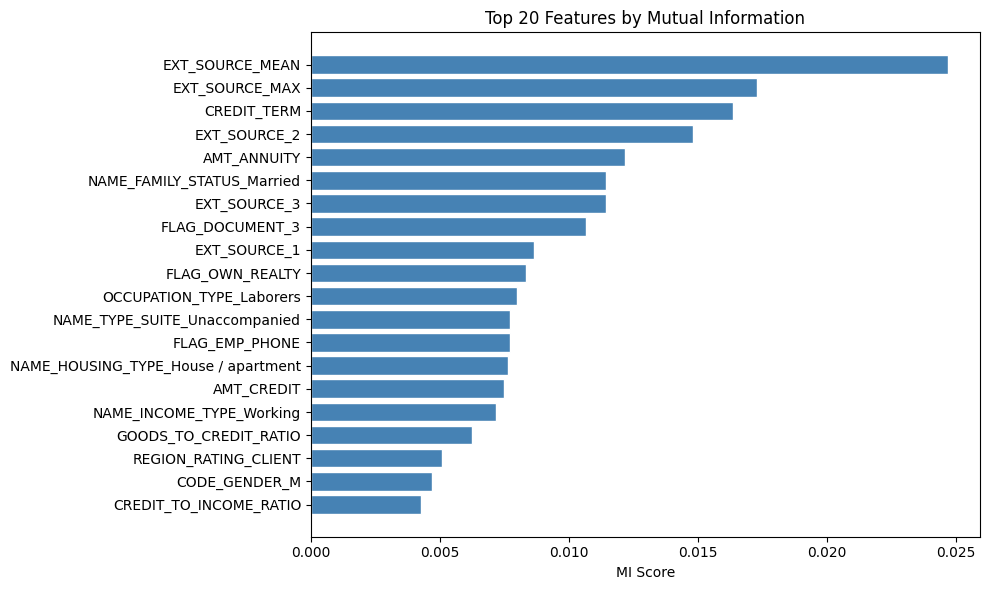

In [5]:
# Plot top 20
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(mi_df.head(20)['Feature'][::-1], 
        mi_df.head(20)['MI_Score'][::-1],
        color='steelblue', edgecolor='white')
ax.set_title('Top 20 Features by Mutual Information')
ax.set_xlabel('MI Score')
plt.tight_layout()
plt.show()

In [6]:
# Train a lightweight Random Forest for feature importance
rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=7,
    random_state=42, 
    n_jobs=-1,
    class_weight='balanced'
)

# Use sample for speed
rf.fit(X_sample, y_sample)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 20 features by Random Forest Importance:")
print(importance_df.head(20))

Top 20 features by Random Forest Importance:
                                 Feature  Importance
90                       EXT_SOURCE_MEAN    0.238167
91                        EXT_SOURCE_MAX    0.149527
23                          EXT_SOURCE_2    0.104404
24                          EXT_SOURCE_3    0.073701
22                          EXT_SOURCE_1    0.049506
8                          DAYS_EMPLOYED    0.044522
89                 GOODS_TO_CREDIT_RATIO    0.034439
7                             DAYS_BIRTH    0.029365
88                           CREDIT_TERM    0.028705
27                DAYS_LAST_PHONE_CHANGE    0.024200
44  NAME_EDUCATION_TYPE_Higher education    0.017185
10                       DAYS_ID_PUBLISH    0.016804
5                             AMT_CREDIT    0.015224
6                            AMT_ANNUITY    0.014724
9                      DAYS_REGISTRATION    0.014277
87                CREDIT_TO_INCOME_RATIO    0.012351
43              NAME_INCOME_TYPE_Working    0.011699
3

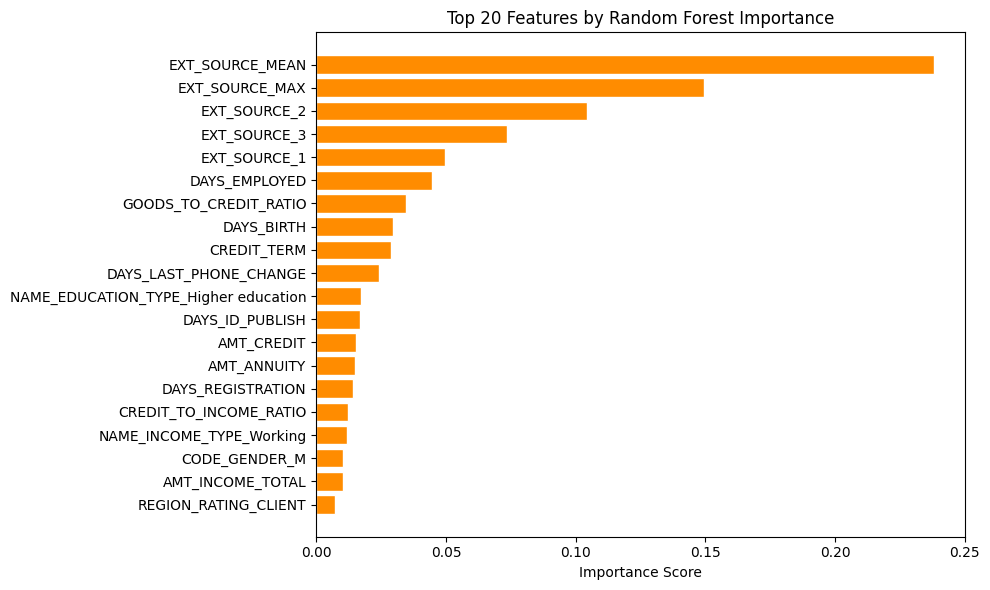

In [7]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df.head(20)['Feature'][::-1],
        importance_df.head(20)['Importance'][::-1],
        color='darkorange', edgecolor='white')
ax.set_title('Top 20 Features by Random Forest Importance')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [8]:
# Take top 50 features from Random Forest importance
top_features = importance_df.head(50)['Feature'].tolist()

# Always keep our engineered features if they made the cut
engineered = [
    'CREDIT_TO_INCOME_RATIO', 'ANNUITY_TO_INCOME_RATIO', 'CREDIT_TERM',
    'GOODS_TO_CREDIT_RATIO', 'EMPLOYMENT_TO_AGE_RATIO', 'INCOME_PER_PERSON',
    'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'EXT_SOURCE_MAX', 'EXT_SOURCE_STD'
]

# Combine and deduplicate
final_features = list(set(top_features + engineered))
print(f"Final selected features: {len(final_features)}")

# Check which engineered features made top 50
print("\nEngineered features in top 50:")
for f in engineered:
    status = "✅ IN" if f in top_features else "➕ ADDED"
    print(f"  {status}: {f}")

Final selected features: 55

Engineered features in top 50:
  ✅ IN: CREDIT_TO_INCOME_RATIO
  ➕ ADDED: ANNUITY_TO_INCOME_RATIO
  ✅ IN: CREDIT_TERM
  ✅ IN: GOODS_TO_CREDIT_RATIO
  ➕ ADDED: EMPLOYMENT_TO_AGE_RATIO
  ➕ ADDED: INCOME_PER_PERSON
  ✅ IN: EXT_SOURCE_MEAN
  ➕ ADDED: EXT_SOURCE_MIN
  ✅ IN: EXT_SOURCE_MAX
  ➕ ADDED: EXT_SOURCE_STD


In [9]:
# Build final dataframe
df_final = df[final_features + ['TARGET']].copy()

print(f"Final dataset shape: {df_final.shape}")
print(f"Target distribution:\n{df_final['TARGET'].value_counts(normalize=True).round(3)}")

df_final.to_csv('../data/processed/final_data.csv', index=False)
print("Saved to data/processed/final_data.csv")

Final dataset shape: (307511, 56)
Target distribution:
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64
Saved to data/processed/final_data.csv
